In [ ]:
import os
from pathlib import Path 

import rioxarray as rxr
from rioxarray.merge import merge_arrays

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter

# Functions

In [106]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    """Truncate a colormap."""
    new_cmap = mcolors.LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

# Load/Process Data

In [107]:
# Define filepaths
root_dir = Path().resolve().parents[1]
dem_dir = root_dir / 'data' / 'geospatial' / 'sci-dem' / 'download'
dem_fpaths =  [dem_dir / 'USGS_13_n35w120.tif', dem_dir / 'USGS_13_n34w120.tif']  # SCI is split between two files
wrf_terrain_fpath = root_dir / 'data' / 'geospatial' / 'wrf-terrain-dem' / 'wrf-terrain.tif'

# Load Data
ocean = cfeature.NaturalEarthFeature(category='physical', name='ocean',  # Ocean mask
                                             scale='10m',
                                             facecolor='blue')

wrf_ter = rxr.open_rasterio(wrf_terrain_fpath).squeeze()
dem1 = rxr.open_rasterio(dem_fpaths[0], masked=True).squeeze()
dem2 = rxr.open_rasterio(dem_fpaths[1], masked=True).squeeze()
dem = merge_arrays([dem1, dem2])  # Merge the arrays

In [108]:
print("WRF CRS: ", wrf_ter.rio.crs)
print("DEM CRS: ", dem.rio.crs)

WRF CRS:  EPSG:4326
DEM CRS:  EPSG:4269


In [109]:
dem = dem.where(dem >= 0, 0)
dem = dem.rio.reproject(wrf_ter.rio.crs)
dem = dem.rio.clip_box(*wrf_ter.rio.bounds())  # * Unpacks into separate args

In [110]:
print(wrf_ter.rio.bounds())
print(dem.rio.bounds())

(-119.93474578857422, 33.940330505371094, -119.4986343383789, 34.09551239013672)
(-119.9348186525429, 33.94027815149528, -119.4986146189007, 34.095556046723026)


# Plot

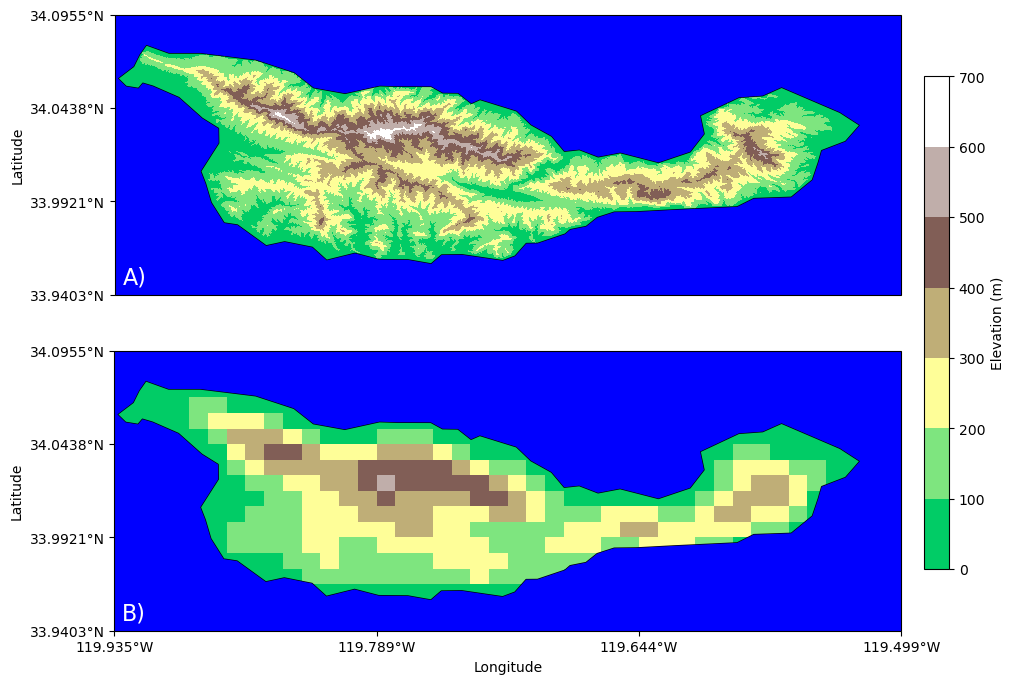

In [112]:
bounds = wrf_ter.rio.bounds()

# Define colormap
terrain = plt.get_cmap('terrain')
color_map = truncate_colormap(terrain, minval=0.25, maxval=1.0)  # Start at green, not blue
cbar_shrink = 0.8

# Make colormap discrete intervals
levels = np.linspace(0, 700, 8) 
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=color_map.N)

# Make plots
fig, ax = plt.subplots(2, 1, figsize=(15, 8), subplot_kw={'projection' : ccrs.PlateCarree()})
dem_plot = dem.plot(ax=ax[0], cmap=color_map, add_colorbar=False, norm=norm)
ax[0].coastlines()
ax[0].add_feature(ocean)
ax[0].set(title='',
          xlabel='Longitude',
          ylabel='Latitude')
ax[0].text(0.01, 0.02, 'A)', transform=ax[0].transAxes,
           fontsize=16, ha='left', va='bottom', color='white')

wrf_plot = wrf_ter.plot(ax=ax[1], cmap=color_map, add_colorbar=False, norm=norm)
ax[1].coastlines()
ax[1].add_feature(ocean)
ax[1].set(title='',
          xlabel='Longitude',
          ylabel='Latitude')
ax[1].text(0.01, 0.02, 'B)', transform=ax[1].transAxes,
           fontsize=16, ha='left', va='bottom', color='white')

# Adjust lat/lon ticks
ax[1].set_xticks(np.linspace(bounds[0], bounds[2], 4), crs=ccrs.PlateCarree())
for a in ax: 
    a.set_yticks(np.linspace(bounds[1], bounds[3], 4), crs=ccrs.PlateCarree())
    lon_formatter = LongitudeFormatter(zero_direction_label=True)
    lat_formatter = LatitudeFormatter()
    a.xaxis.set_major_formatter(lon_formatter)
    a.yaxis.set_major_formatter(lat_formatter)

# Add centered colorbar on right
cbar = fig.colorbar(wrf_plot, ax=ax, orientation='vertical', fraction=0.04, pad=0.02, shrink=cbar_shrink)
cbar.set_label('Elevation (m)')

plt.show()